In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [5]:
os.getcwd()
os.chdir('/Users/nitheshsrb/Downloads')

In [25]:
df = pd.read_excel('open-meteo-51.49N0.16W23m.xlsx')

In [122]:
df.head()

2,time,temperature_2m_mean (°C),temperature_2m_max (°C),temperature_2m_min (°C),snowfall_sum (cm),rain_sum (mm),precipitation_sum (mm),surface_pressure_mean (hPa),pressure_msl_mean (hPa),wind_gusts_10m_mean (km/h),...,cloud_cover_mean (%),wind_speed_10m_mean (km/h),wind_speed_10m_max (km/h),pressure_msl_max (hPa),wet_bulb_temperature_2m_mean (°C),soil_temperature_0_to_100cm_mean (°C),soil_moisture_0_to_100cm_mean (m³/m³),year,month,Year-Month
3,2018-01-01,6,7.3,4.6,0,2.3,2.3,996,998.8,36.7,...,58,20.8,30.4,1006.7,4.1,7.1,0.396,2018,1,2018 - 1
4,2018-01-02,7,12.2,2.3,0,7.7,7.7,1002,1004.8,42.1,...,80,22.3,40.6,1011.1,5.6,6.8,0.396,2018,1,2018 - 1
5,2018-01-03,8.4,12,6.8,0,1.8,1.8,993,995.7,62.4,...,26,36.1,43.4,1001.1,5.2,7.2,0.4,2018,1,2018 - 1
6,2018-01-04,8.2,12.6,5.8,0,4.4,4.4,991.8,994.5,41.4,...,69,23.2,41.1,1000.7,6.2,7.2,0.402,2018,1,2018 - 1
7,2018-01-05,5.4,8.5,1.9,0,0.8,0.8,991.8,994.6,27.5,...,68,15.2,29,999.4,3.9,7.1,0.404,2018,1,2018 - 1


In [129]:
df.isnull().sum()

2
time                                     0
temperature_2m_mean (°C)                 0
temperature_2m_max (°C)                  0
temperature_2m_min (°C)                  0
snowfall_sum (cm)                        0
rain_sum (mm)                            0
precipitation_sum (mm)                   0
surface_pressure_mean (hPa)              0
pressure_msl_mean (hPa)                  0
wind_gusts_10m_mean (km/h)               0
wind_direction_10m_dominant (°)          0
et0_fao_evapotranspiration (mm)          0
precipitation_hours (h)                  0
dew_point_2m_mean (°C)                   0
cloud_cover_mean (%)                     0
wind_speed_10m_mean (km/h)               0
wind_speed_10m_max (km/h)                0
pressure_msl_max (hPa)                   0
wet_bulb_temperature_2m_mean (°C)        0
soil_temperature_0_to_100cm_mean (°C)    0
soil_moisture_0_to_100cm_mean (m³/m³)    0
year                                     0
month                                    0
Year-Mont

In [ ]:
df.columns = df.loc[2]
df = df.loc[3:]

In [ ]:
df['time'] = pd.to_datetime(arg = df['time'], format = '%Y-%m-%d')

In [95]:
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month
df['Year-Month'] = df['year'].astype('str') + ' - ' + df['month'].astype('str')

In [96]:
df['Year-Month'].head()

3    2018 - 1
4    2018 - 1
5    2018 - 1
6    2018 - 1
7    2018 - 1
Name: Year-Month, dtype: str

In [52]:
df[df['year'] == 2018]['temperature_2m_max (°C)'].sort_values(ascending=False)

209    32.7
210    30.9
220    30.2
217    30.2
206      30
       ... 
60      1.4
79      0.9
63      0.5
62      0.1
61     -0.7
Name: temperature_2m_max (°C), Length: 365, dtype: object

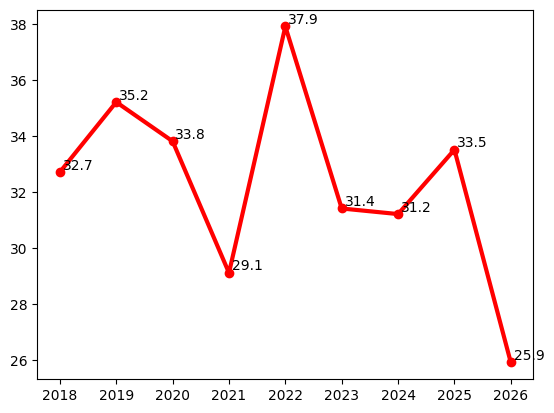

In [84]:
max_temp = df.groupby('year')['temperature_2m_max (°C)'].max().reset_index()

plt.plot(max_temp['year'],max_temp['temperature_2m_max (°C)'],linewidth = 3, color = 'red',marker = 'o')
for i, (year,val) in enumerate(zip(max_temp['year'],max_temp['temperature_2m_max (°C)'])):
    plt.annotate(str(val)
                 ,xy = (year,val)
                 , xytext = (2,2)
                 ,textcoords='offset points')

<Axes: ylabel='Density'>

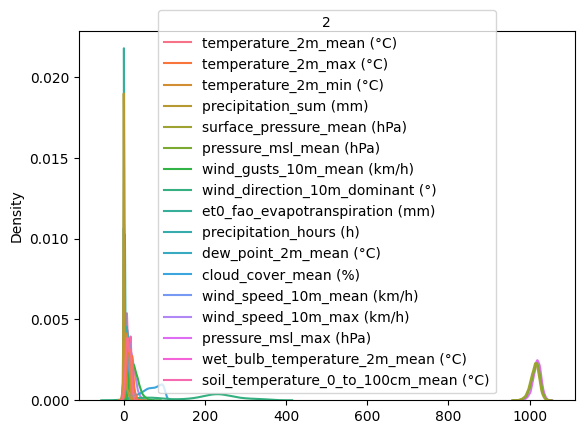

In [111]:
temp = df.drop(columns = ['snowfall_sum (cm)','rain_sum (mm)','year','month','soil_moisture_0_to_100cm_mean (m³/m³)'])
sns.kdeplot(data = temp)

<Axes: ylabel='Density'>

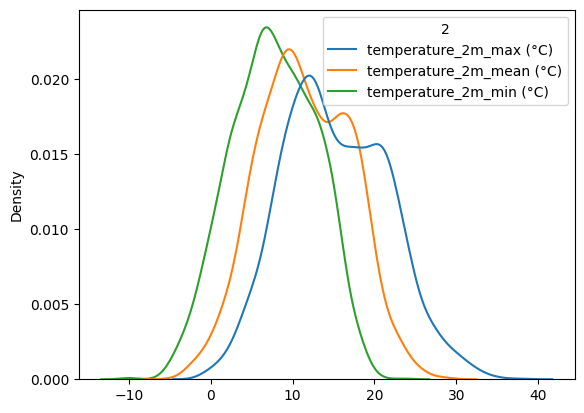

In [119]:
temperatures = df[['temperature_2m_max (°C)','temperature_2m_mean (°C)','temperature_2m_min (°C)']]
sns.kdeplot(data = temperatures)

<Axes: xlabel='2', ylabel='2'>

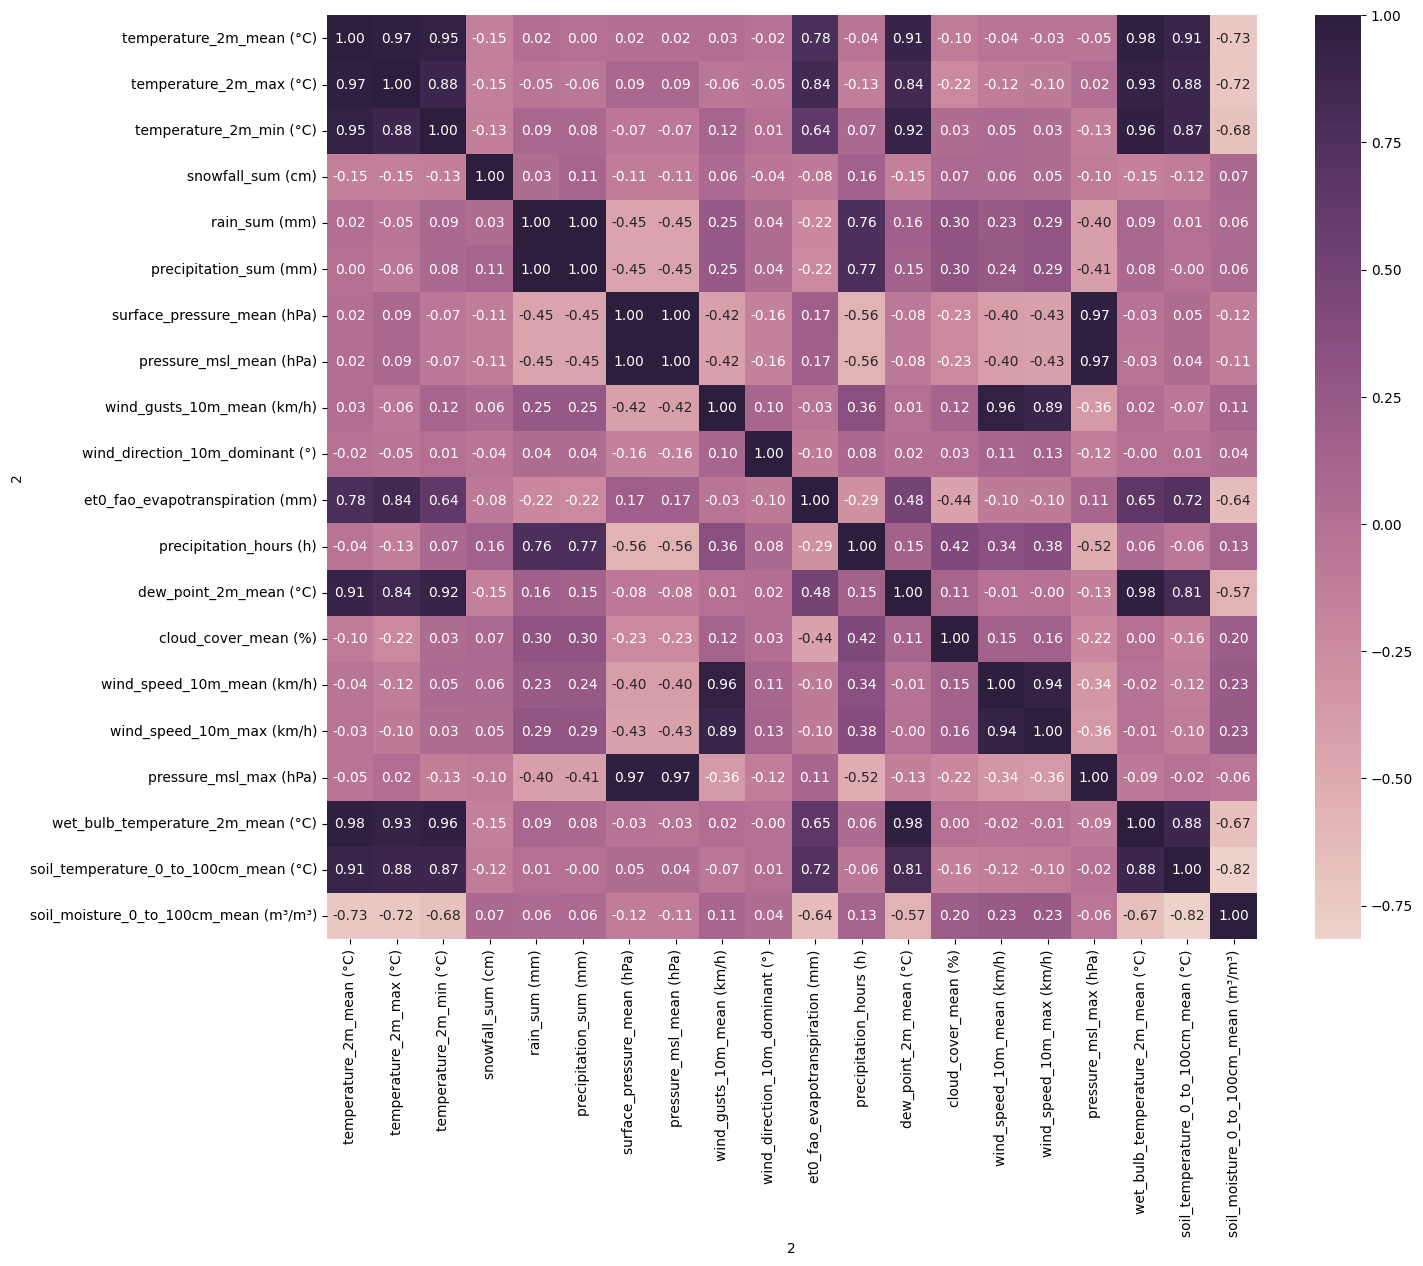

In [130]:
plt.figure(figsize = (15,12))
corr_df = df.drop(columns=['year','month','Year-Month','time'])

r = corr_df.corr()

sns.heatmap(data = r, cmap = sns.cubehelix_palette(as_cmap=True),fmt = '.2f',annot=True)